# Fitting WR137 in the image plane

In [1]:
# jax ecosystem
import jax

jax.config.update("jax_platform_name", "gpu")
jax.config.update("jax_enable_x64", True)
print(jax.local_devices()[0].device_kind)

from jax import numpy as np, tree as jtu
import zodiax as zdx
from zodiax.optimisation import sgd, adam
import amigo
import dorito

# other helpful libraries
import numpy
import os
import astropy

# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

NVIDIA GeForce RTX 2080 Ti


/home/max/miniforge3/envs/newb/lib/python3.13/site-packages/amigo/optical_models.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


In [22]:
from socket import gethostname

if gethostname() == "glinton":
    path = "/media/morgana1/snert/max/"
elif gethostname() == "AJQ4YHQH9TX":
    path = "/Volumes/morgana1/snert/max/"
else:
    path = "/fred/oz440/max/"

source_name = "WR137"
data_path = os.path.join(path, f"data/JWST/{source_name}/calslope/")
uncal_path = os.path.join(path, f"data/JWST/{source_name}/uncal/")
amigo_cache = os.path.join(path, "data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, f"outputs/{source_name}/")

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    # "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

# Loading in data

In [23]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
sci_files = []
cal_files = []

for file in files:

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 228337"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(sci_files, 50)

In [24]:
from astropy.time import Time

t0 = Time(0, format="mjd")
for file in files:
    h = file[0].header
    t = Time(h["EXPMID"], format="mjd")

    if t.ymdhms[2] != t0.ymdhms[2]:
        print("\n" + 30 * "-" + "\n")

    print(
        f'{h["TARGPROP"]} {h["FILTER"]}, Dither {h["PATT_NUM"]}/{h["NUMDTHPT"]}, Roll {h["ROLL_REF"]:.1f}deg, {h["XPOSURE"] / 60:.1f}min, {t.iso}, Groups: {h["NGROUPS"]}, Ints: {h["NINTS"]}'
    )
    t0 = t


------------------------------

WR137 F480M, Dither 1/4, Roll 192.0deg, 2.0min, 2022-07-13 11:42:10.194, Groups: 4, Ints: 400
WR137 F480M, Dither 2/4, Roll 192.0deg, 2.0min, 2022-07-13 11:46:01.618, Groups: 4, Ints: 400
WR137 F480M, Dither 3/4, Roll 192.0deg, 2.0min, 2022-07-13 11:49:54.065, Groups: 4, Ints: 400
WR137 F480M, Dither 4/4, Roll 192.0deg, 2.0min, 2022-07-13 11:53:45.553, Groups: 4, Ints: 400

------------------------------

HD 228337 F480M, Dither 1/1, Roll 189.5deg, 9.0min, 2022-07-15 11:42:00.230, Groups: 7, Ints: 1020
WR137 F480M, Dither 1/4, Roll 189.8deg, 8.0min, 2022-07-15 12:38:42.741, Groups: 4, Ints: 1600

------------------------------

WR137 F480M, Dither 1/4, Roll 162.7deg, 2.0min, 2022-08-08 18:44:08.571, Groups: 4, Ints: 400
WR137 F480M, Dither 2/4, Roll 162.7deg, 2.0min, 2022-08-08 18:47:59.995, Groups: 4, Ints: 400
WR137 F480M, Dither 3/4, Roll 162.7deg, 2.0min, 2022-08-08 18:51:51.419, Groups: 4, Ints: 400
WR137 F480M, Dither 4/4, Roll 162.7deg, 2.0min, 2

/home/max/miniforge3/envs/newb/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


## Building the model

In [32]:
class OsampPointFit(amigo.model_fits.PointFit):

    def simulate(self, model, return_slopes=True):
        model = self.nuke_pixel_grads(model)
        psf = self.model_psf(model)

        #################################################################
        # Add the extra downsample to the 3x oversample for the detector/ramp
        psf = psf.downsample(model.source_oversample)
        #################################################################

        illuminance = self.model_illuminance(psf, model)
        ramp = self.model_ramp(illuminance, model)
        ramp = self.model_read(ramp, model)

        if return_slopes:
            return ramp.set("data", np.diff(ramp.data, axis=0))
        return ramp


class MonthPointFit(OsampPointFit):

    date: str  # isot
    month: str
    dith: str

    def __init__(self, file, use_cov=True):
        expmid = Time(file[0].header["EXPMID"], format="mjd")
        self.date = str(expmid.isot)
        self.month = f"{expmid.ymdhms[1]:02d}"
        super().__init__(file, use_cov=use_cov)
        self.dith = "ST" if self.month == "07" else self.dither

    def get_key(self, param):
        # Return the per exposure key if not joint fitting
        match param:
            case "aberrations":
                return "_".join([self.dith, self.filter])

        return super().get_key(param)


class MonthResolvedFit(dorito.model_fits.ResolvedFit):

    date: str  # isot
    month: str
    dith: str

    def __init__(self, file, use_cov=True):
        expmid = Time(file[0].header["EXPMID"], format="mjd")
        self.date = str(expmid.isot)
        self.month = f"{expmid.ymdhms[1]:02d}"
        super().__init__(file, use_cov=use_cov)
        self.dith = "ST" if self.month == "07" else self.dither

    def get_key(self, param):
        # Return the per exposure key if not joint fitting
        match param:
            case "aberrations":
                return "_".join([self.dith, self.filter])

        return super().get_key(param)

In [39]:
source_size = 11  # pixels
load_dict = lambda x: np.load(f"{x}", allow_pickle=True).item()

# sci_fits = [dorito.model_fits.ResolvedFit(file, use_cov=True) for file in sci_files]
sci_fits = [MonthResolvedFit(file, use_cov=True) for file in sci_files]
# cal_fits = [amigo.model_fits.PointFit(file, use_cov=True) for file in cal_files]
cal_fits = [MonthPointFit(file, use_cov=True) for file in cal_files]
# fits = sci_fits + cal_fits
fits = sci_fits[4:] + cal_fits
# fits = sci_fits[4:5] + cal_fits[0:1]

# building the model
source_osamp = 2
model = dorito.models.ResolvedAmigoModel(
    exposures=fits,
    optics=amigo.optical_models.AMIOptics(oversample=3 * source_osamp),
    detector=amigo.detector_models.LinearDetector(),
    ramp_model=amigo.ramp_models.NonLinearRamp(),
    read=amigo.read_models.ReadModel(),
    state=load_dict(cache + "calibration.npy"),
    source_oversample=source_osamp,
    param_initers={
        "distribution": np.ones((source_size, source_size)) / source_size**2,
    },
)

In [40]:
for fit in fits:
    print(fit.dith, fit.filter, fit.month, fit.calibrator, fit.dither)

ST F480M 07 False 1
1 F480M 08 False 1
2 F480M 08 False 2
3 F480M 08 False 3
4 F480M 08 False 4
ST F480M 07 True 1
1 F480M 08 True 1
2 F480M 08 True 2
3 F480M 08 True 3
4 F480M 08 True 4


In [7]:
# for exp in fits:
#     exp.print_summary()
#     amigo.plotting.summarise_fit(model, exp, residuals=False)

## Optimisation Stage 1: Gradient Descent

In [8]:
pos_keys = []
spc_keys = []
for exp in fits:
    if not exp.calibrator:
        pos_keys.append(exp.map_param("positions"))
        spc_keys.append(exp.map_param("spectra"))


def norm_fn(model_params, args):
    params = model_params.params
    if "log_dist" in params.keys():

        for filt in params["log_dist"].keys():
            log_dist = params["log_dist"][filt]
            dist = 10**log_dist

            # normalising the distribution
            params["log_dist"][filt] = np.log10(dist / dist.sum())

    if "spectra" in params.keys():
        spectra = jtu.map(
            lambda x: np.clip(x, a_min=-0.8, a_max=0.8), params["spectra"]
        )
        params["spectra"] = spectra

    return model_params.set("params", params), args


pscale = lambda model: model.optics.psf_pixel_scale / model.optics.oversample


# def regularised_loss_fn(model, exp, args={"reg_func_dict": {}, "reg_dict": {}}):
#     # this is per exposure

#     # regular likelihood term
#     likelihood = -np.nanmean(exp.mv_zscore(model))

#     # grabbing and exponentiating log distributions
#     prior = apply_regularisers(model, exp, args) if not exp.calibrator else 0.0

#     return likelihood + prior, ()

In [9]:
n_epoch = 100

config = {
    "positions": sgd(2e-1, 0),
    "fluxes": sgd(2e-1, 0),
    "aberrations": sgd(3e-2, 4),
    "spectra": sgd(2e-1, 10),
    "log_dist": adam(1e-1, 30, (1000, 0.75)),
}


def grad_fn(model, grads, args):

    # Reduce spectra gradients for the science exposures
    if "spectra" in config.keys():
        grads = grads.multiply(spc_keys, 0.3)

    return grads, args


args = {
    "reg_dict": {
        # "ME": (1e3, dorito.stats.ME),
    }
}

# x = ramp_posterior_balance(model, sci_fits[0], args)
# print(x)

trainer = amigo.fitting.Trainer(
    # loss_fn=dorito.stats.ramp_regularised_loss_fn,
    norm_fn=norm_fn,
    grad_fn=grad_fn,
    cache=os.path.join(amigo_cache, "fishers/"),
)

print("Populating fishers...")
trainer = trainer.populate_fishers(
    # model.set("detector.ramp.bleed", False).set("params", params),
    model,
    fits,
    hessians=load_dict(cache + "jacobians.npy")["hessian"],
    parameters=[p for p in config.keys()],  # if p not in ["log_dist"]],
)

print("Number of exposures: ", len(fits))

# Train the model
# with jax.profiler.trace("/tmp/jax-trace", create_perfetto_link=True):
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=fits,
    # batches=amigo.fitting.batch_exposures(fits, 4),
    args=args,
)

Populating fishers...


KeyError: log_dist not in hessians for 01349_006_02_03_1, skipped
KeyError: log_dist not in hessians for 01349_005_02_03_1, skipped
Number of exposures:  2


  0%|          | 0/100 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 3,565.16
Estimated run time: 0:02:47
Full Time: 0:03:15
Final Loss: 313.19


In [10]:
import interpax
import lineax
import equinox

print(jax.__version__)
print(interpax.__version__)
print(lineax.__version__)
print(equinox.__version__)

0.7.2.dev20250827+19cb99ab9
0+untagged.200.g040e67a
0.0.8
0.13.0


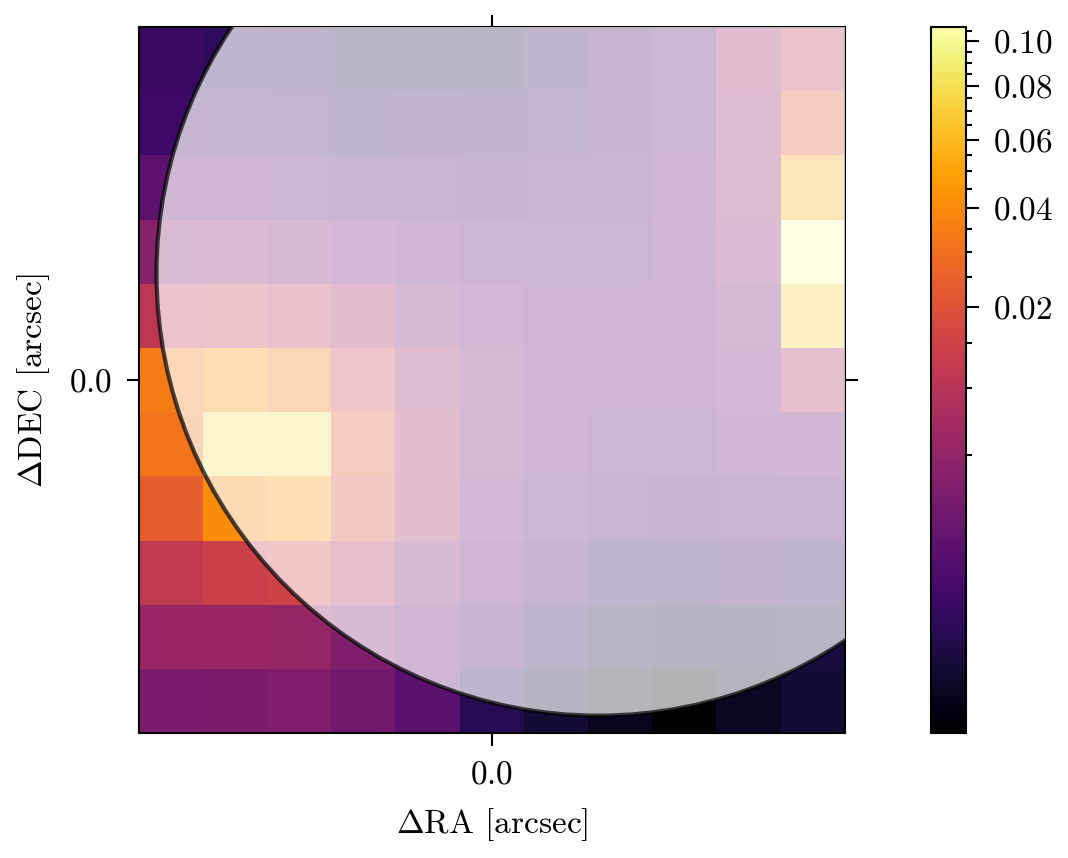

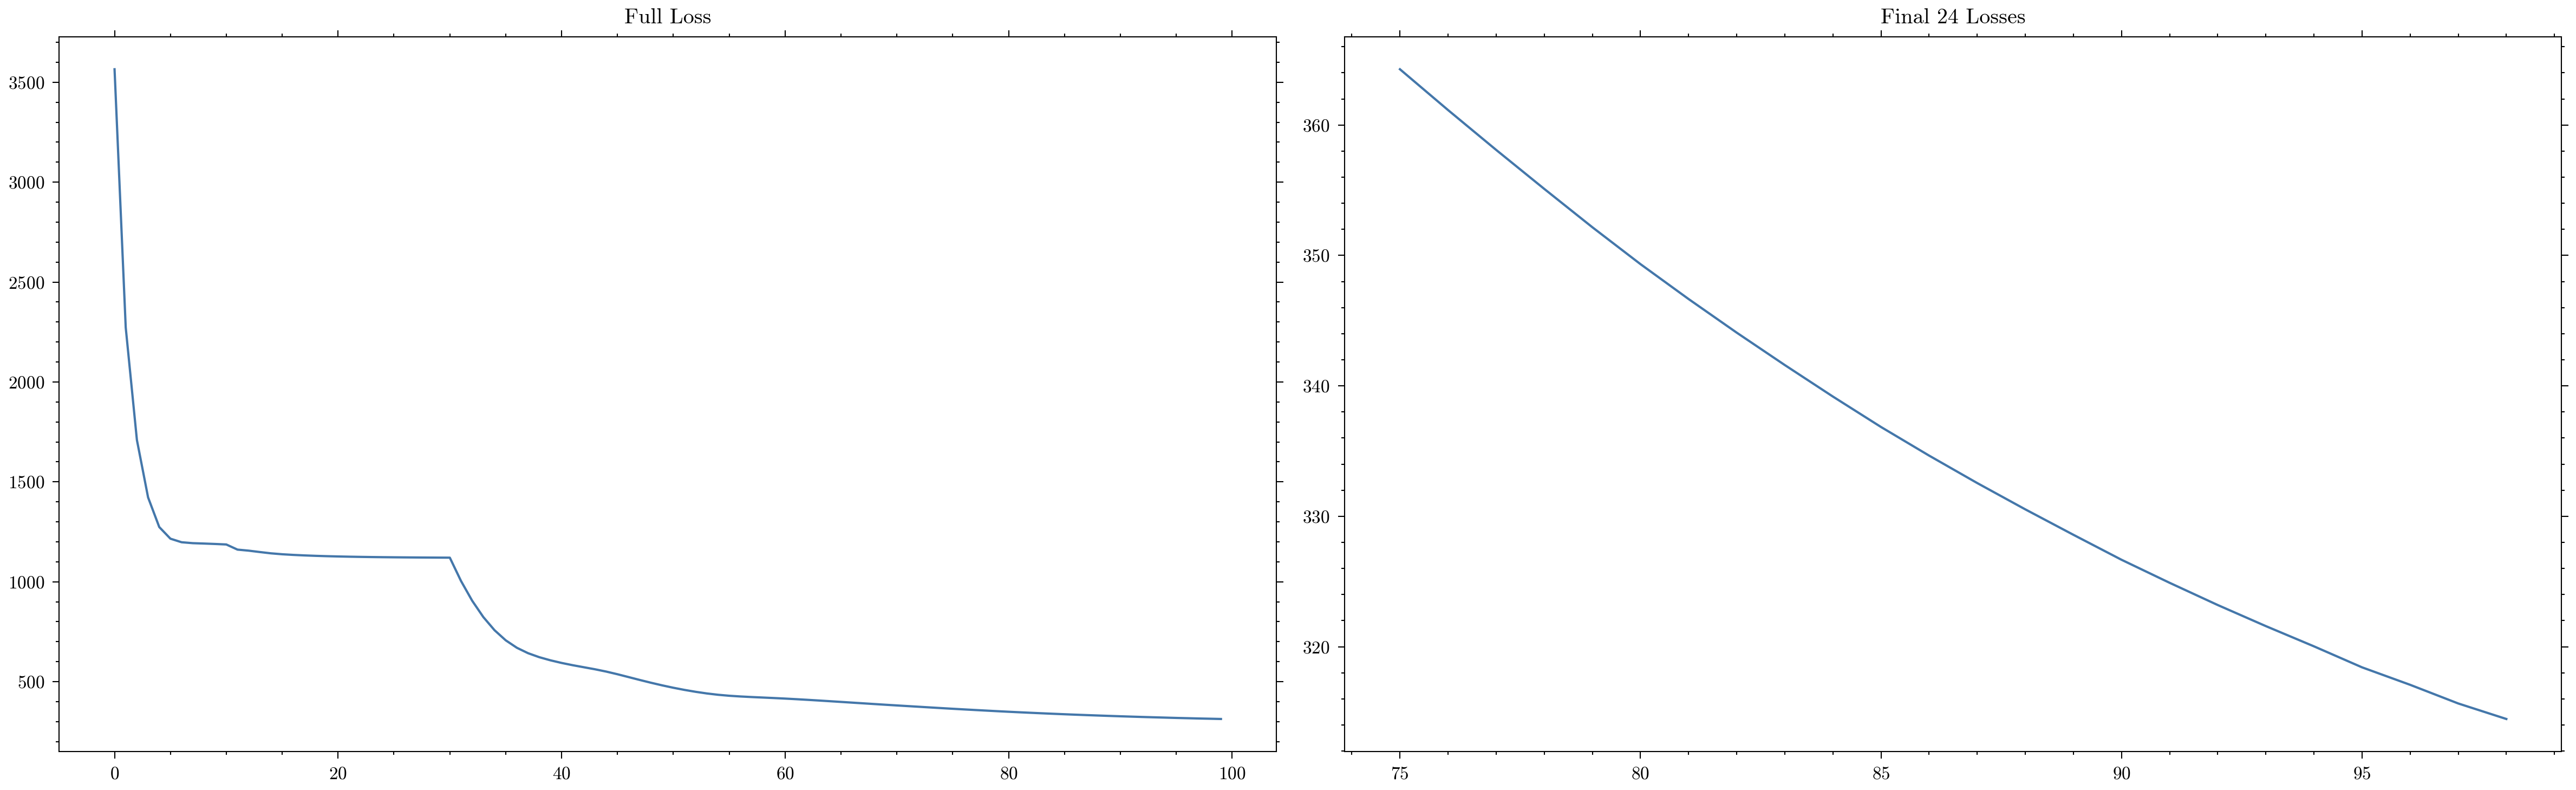

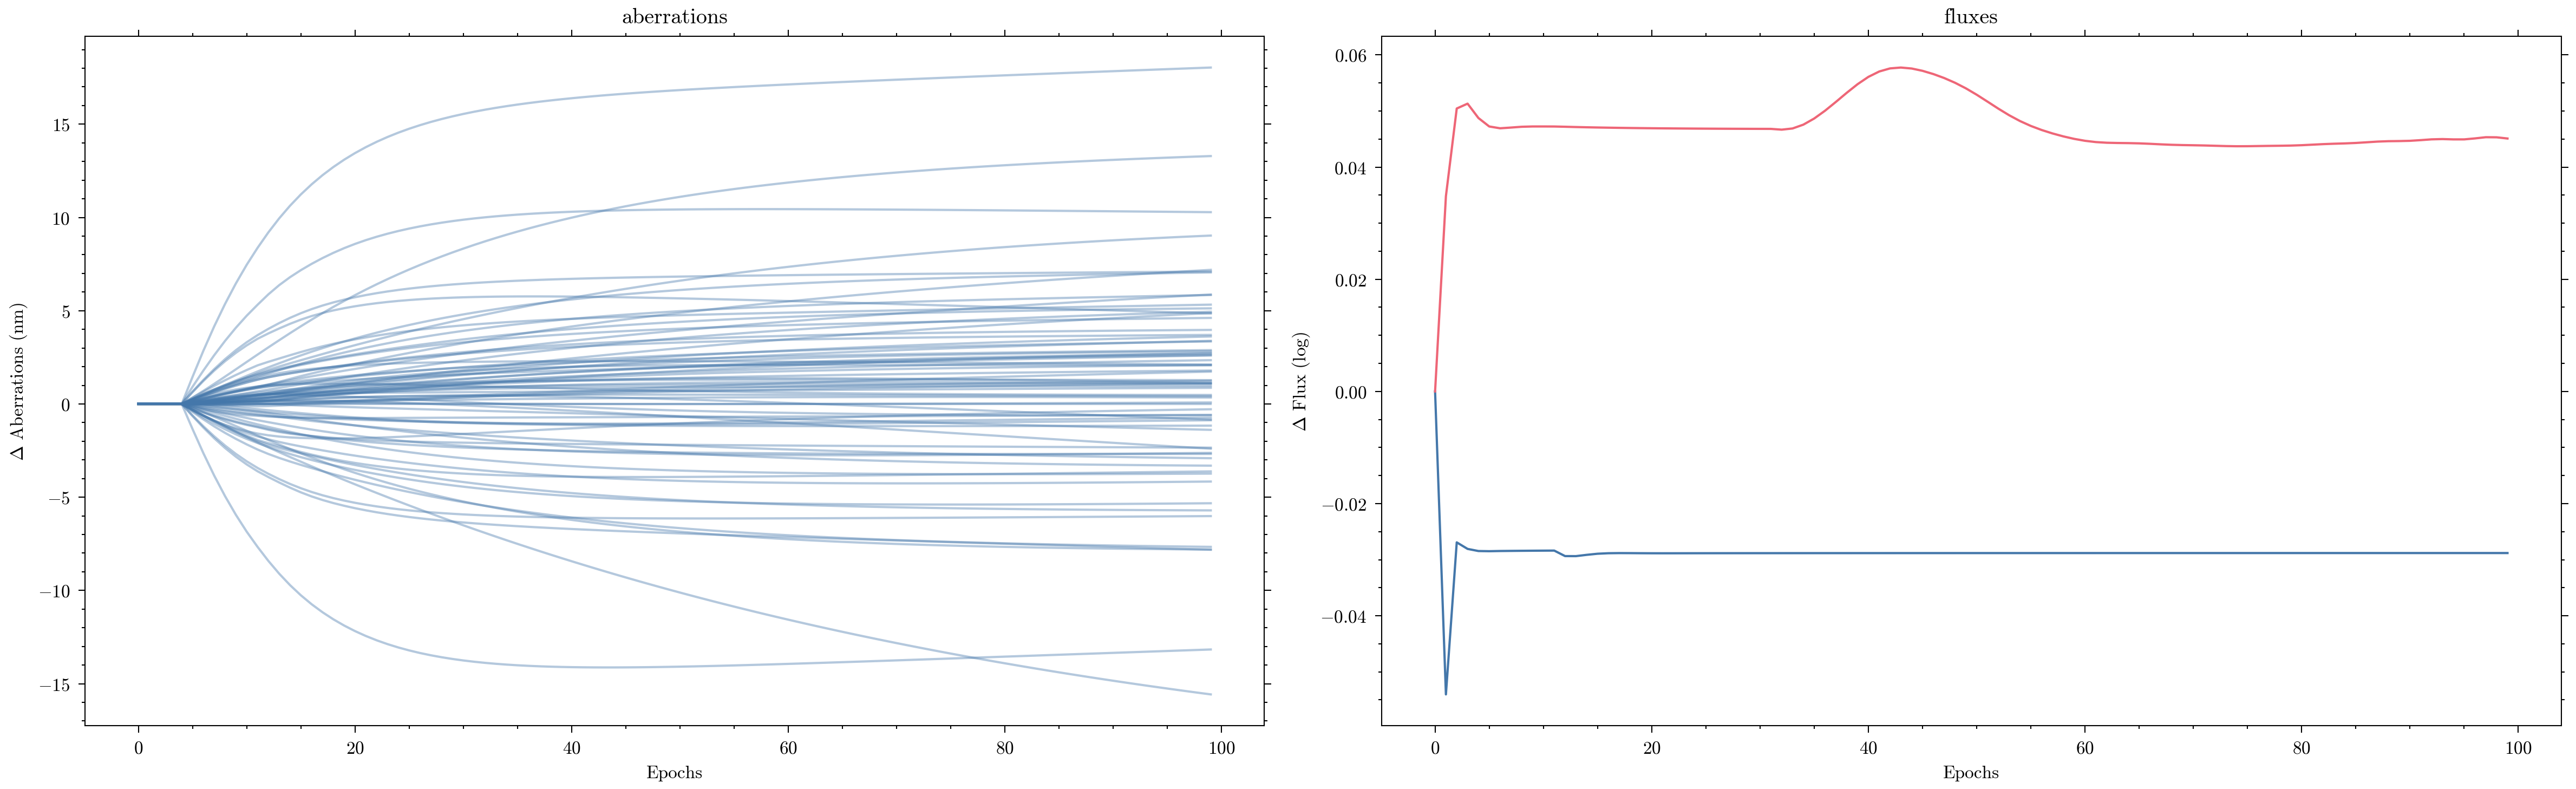

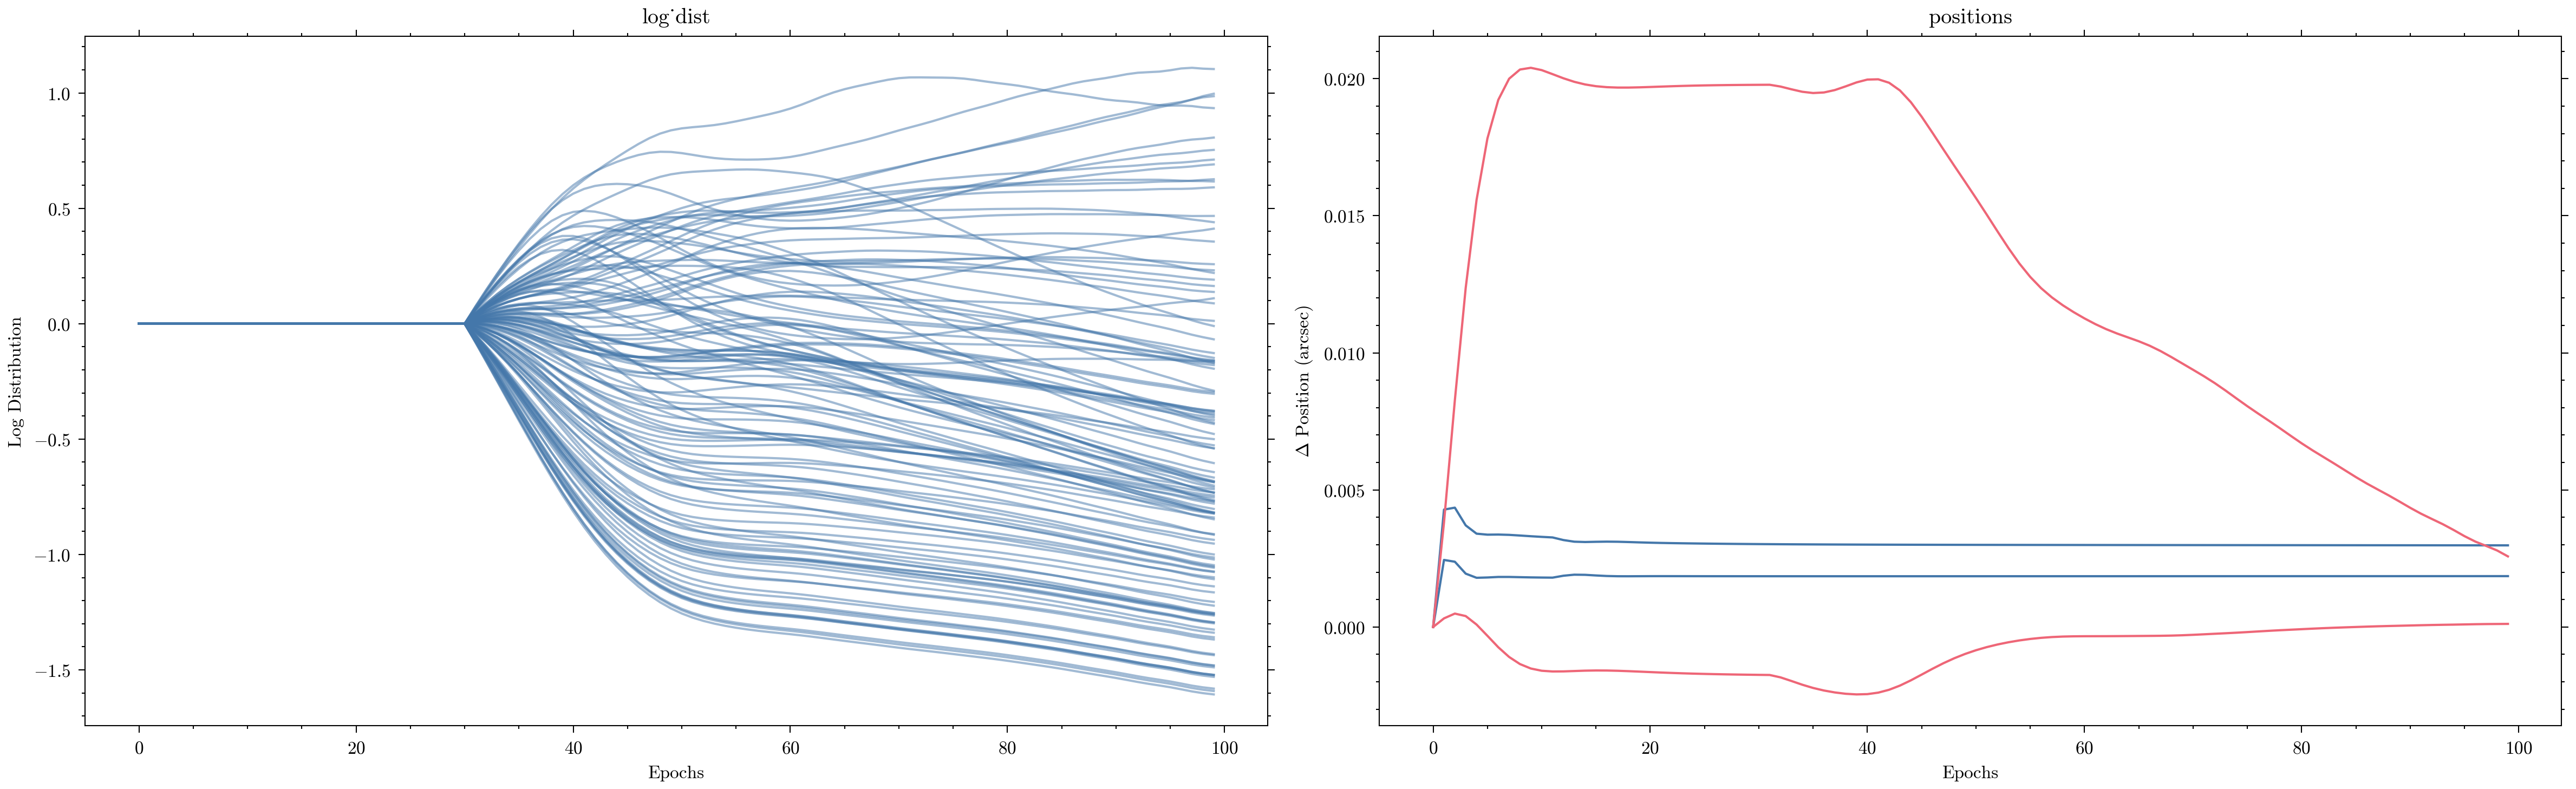

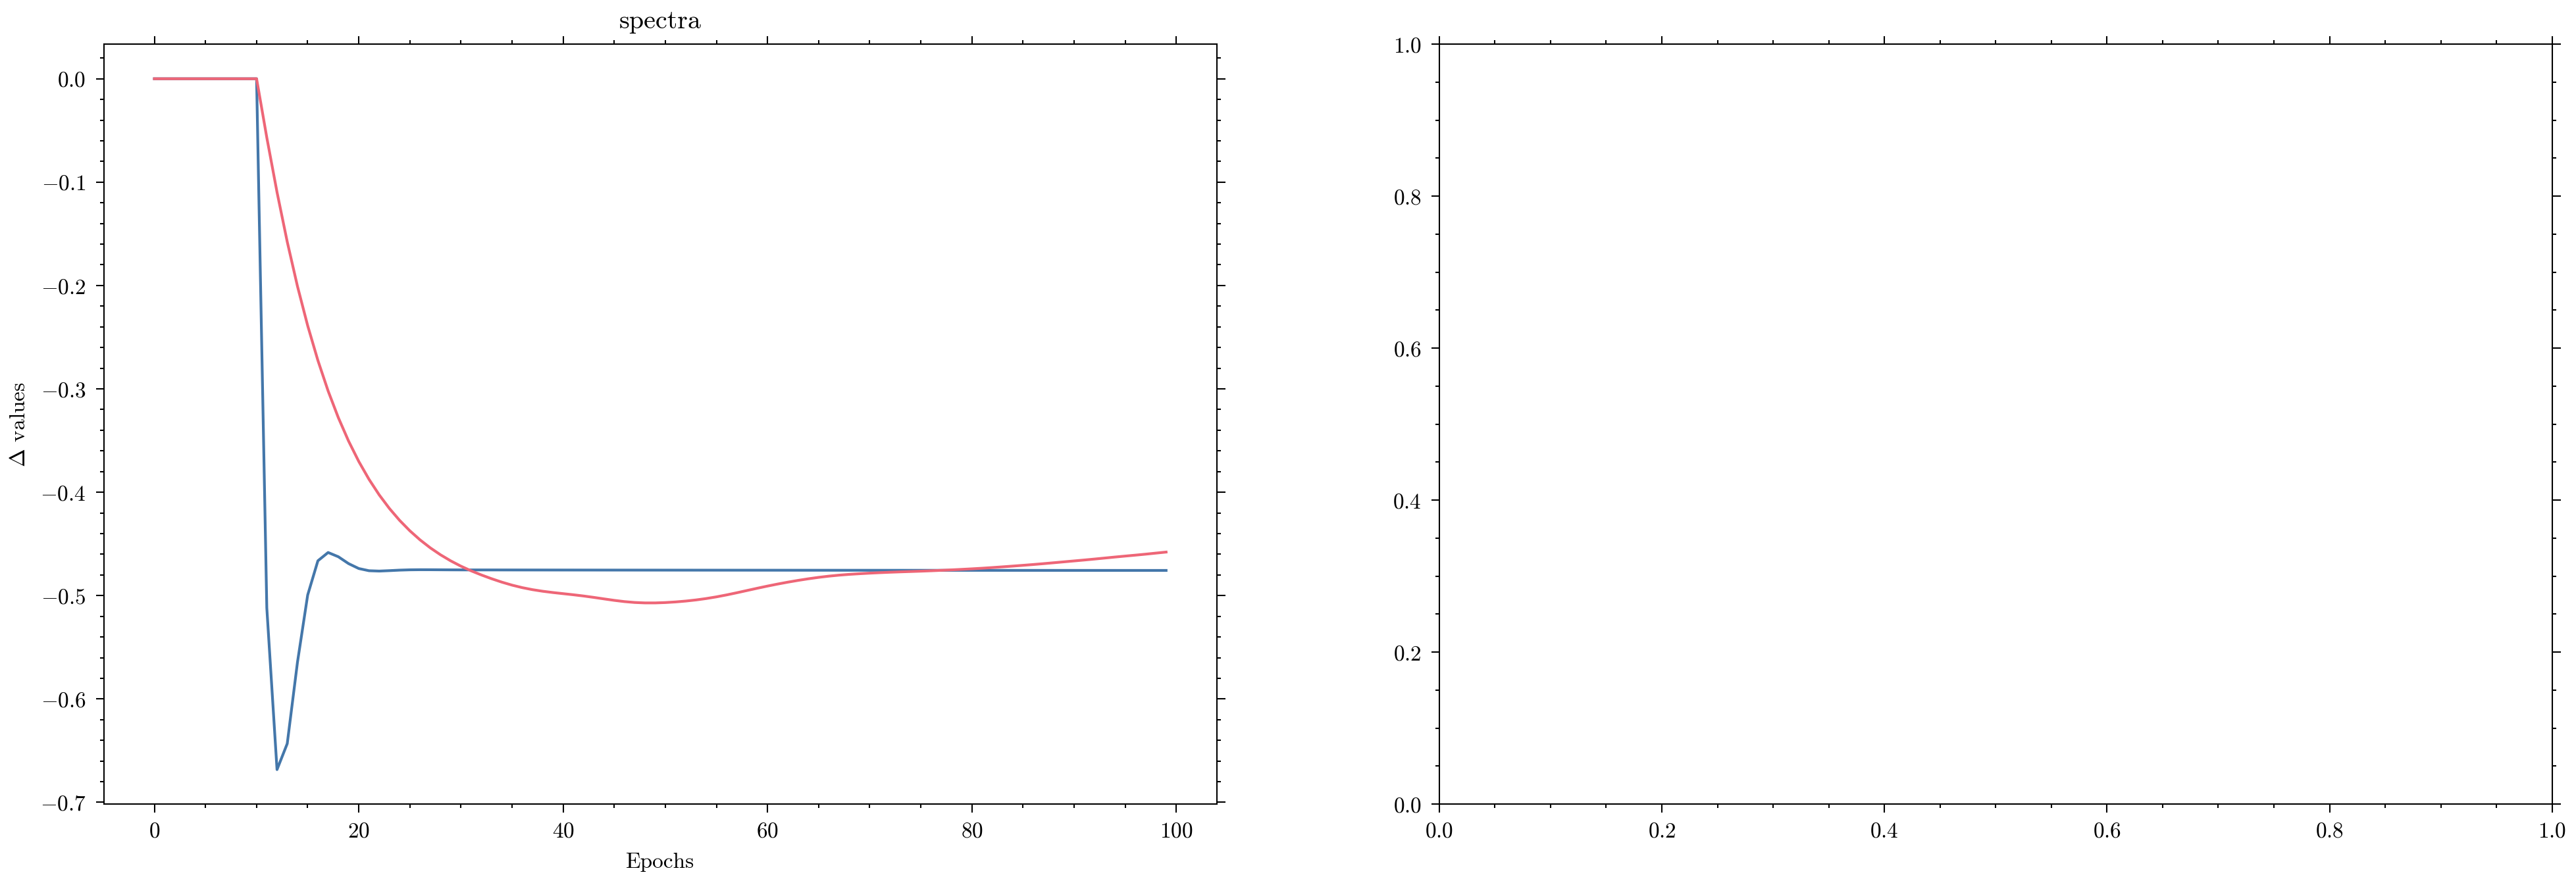

File 01349_006_02_03_1
Star WR137
Filter F480M
nints 1600
ngroups 4



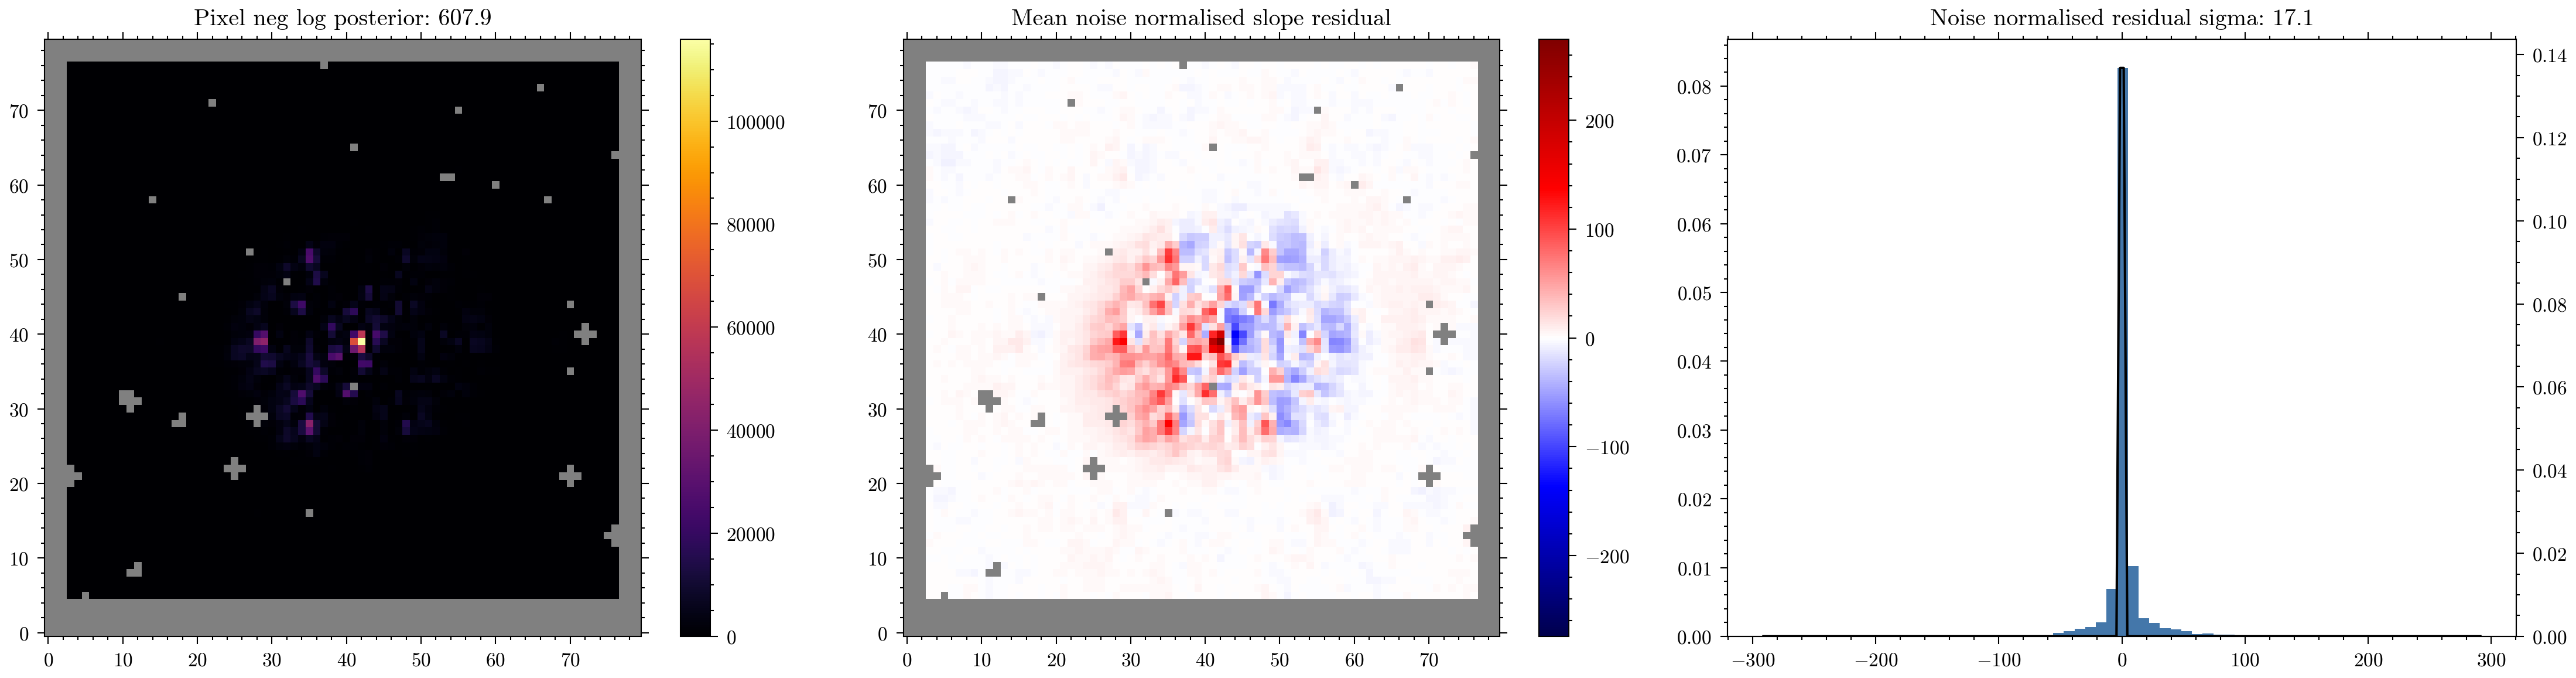

File 01349_005_02_03_1
Star HD 228337
Filter F480M
nints 1020
ngroups 7



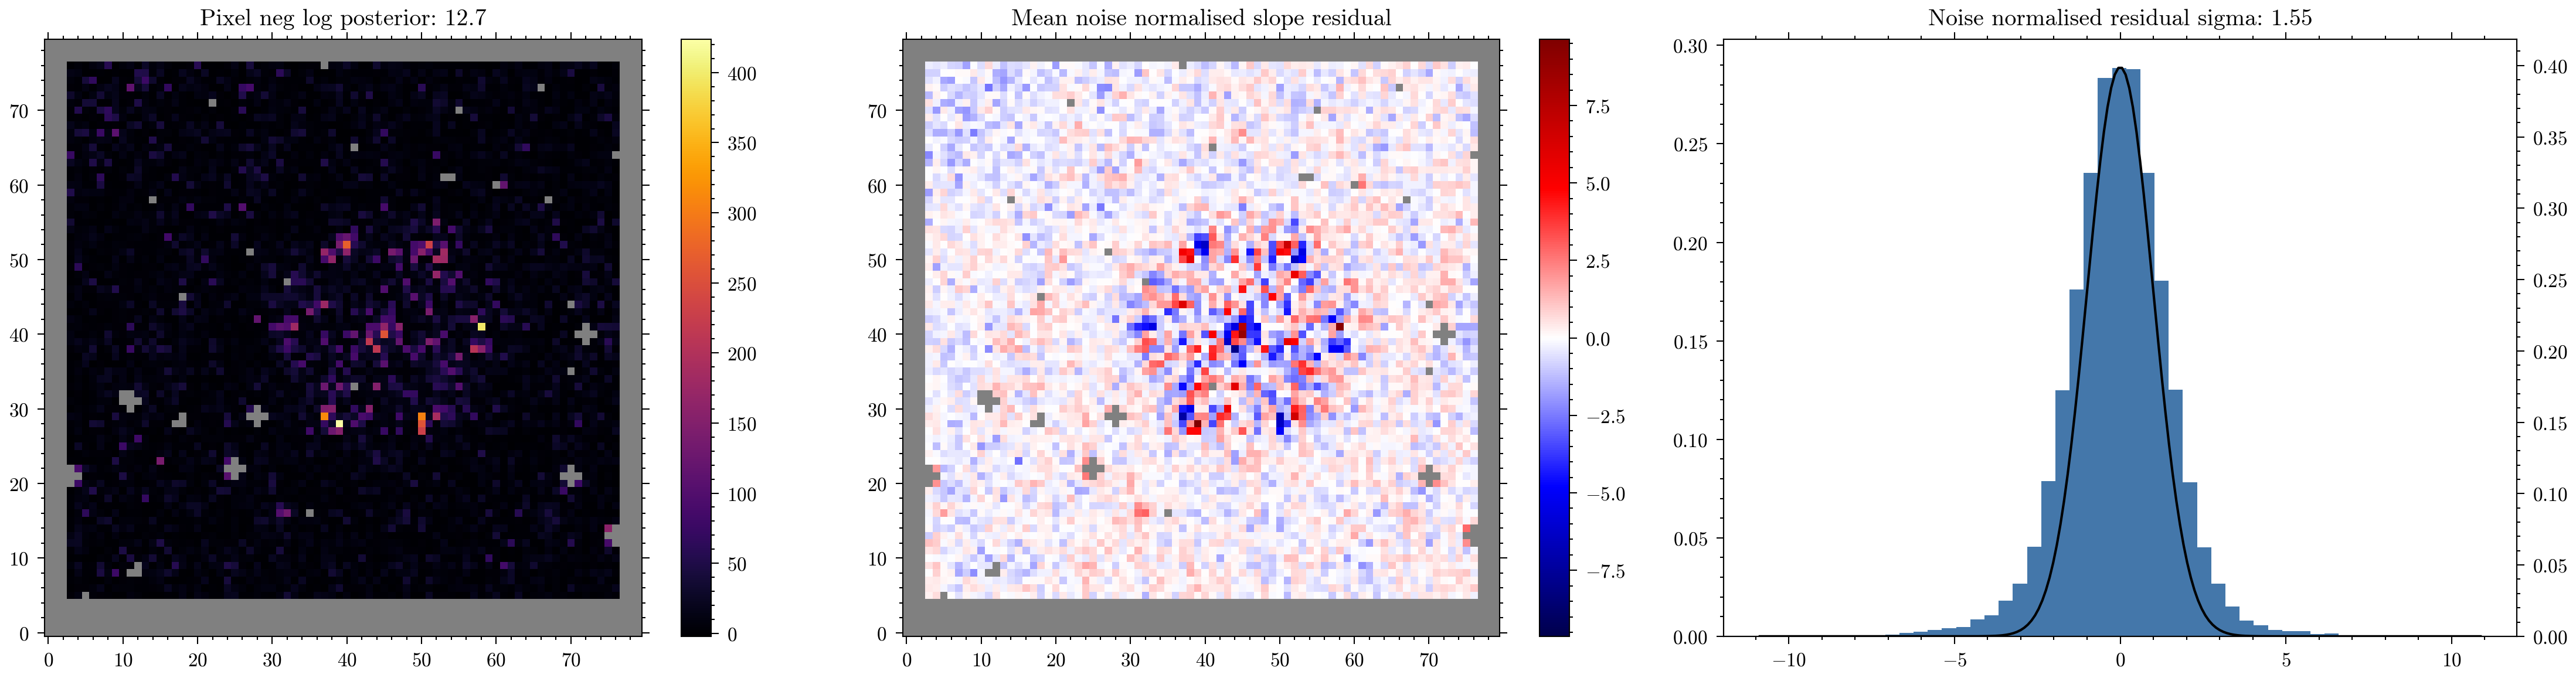

In [11]:
from dLux import utils as dlu


def eff_wavel(model, filt):
    wavels, weights = model.filters[filt]
    return np.dot(wavels, weights)


result_model = result.model


optics_diameter = 6.603464  # JWST aperture diameter in meters

for exp in fits:

    if exp.calibrator:
        continue
    dist = result_model.get_distribution(exp, rotate=False)
    fig, ax = plt.subplots(figsize=(6, 3))

    c0 = dorito.plotting.plot_result(
        ax,
        dist,
        pixel_scale=model.psf_pixel_scale / model.oversample,
        cmap="inferno",
        # roll_angle_degrees=-exp.parang,
        norm=mpl.colors.PowerNorm(0.3),
        # norm=mpl.colors.PowerNorm(0.3, vmax=0.3),
        diff_lim=dlu.rad2arcsec(0.5 * eff_wavel(model, exp.filter) / optics_diameter),
        # scale=1.5,
    )
    fig.colorbar(c0)
    plt.tight_layout()
    plt.show()
    # plt.savefig(output_path + f"{exp.key}_dist.png", dpi=300)

amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)

for exp in fits:
    exp.print_summary()
    amigo.plotting.summarise_fit(result.model, exp)

In [ ]:
from scipy.ndimage import gaussian_filter

pixel_scale = model.psf_pixel_scale / model.oversample

r, g, b = [
    result_model.get_distribution(exp, rotate=False)
    * (10 ** result_model.params["fluxes"][exp.get_key("fluxes")])
    for exp in fits
    if not exp.calibrator
]
# * result_model.params["fluxes"][exp.get_key("fluxes")]

# r = (
#     result_model.get_distribution(fits[0], rotate=False)
#     * result_model.params["fluxes"][fits[0]]
# )
# g = result_model.get_distribution(fits[1], rotate=False)
# b = result_model.get_distribution(fits[2], rotate=False)

eff_wavel = np.array(
    [np.dot(*model.filters[exp.filter]) for exp in fits if exp.calibrator is False]
).mean()


def blur(factor, arr, filter):

    # wavelength in metres
    wavel = np.dot(*model.filters[filter])

    # FWHM in pixels
    lambda_over_d = dlu.rad2arcsec(wavel / model.optics.diameter)  # arcseconds
    lambda_over_d /= pixel_scale  # pixels
    fwhm = factor * lambda_over_d
    sigma = float(fwhm / (2 * (2 * np.log(2)) ** 0.5))

    return gaussian_filter(arr, sigma=(sigma))


fac = 0.25  # factor to scale the FWHM
r = blur(fac, r, "F480M")
g = blur(fac, g, "F430M")
b = blur(fac, b, "F380M")

piccy = np.stack([r, g, b], axis=-1)
piccy /= piccy.max()
piccy = piccy**0.5  # adjust brightness
piccy = np.clip(piccy, 0, 0.2)  # remove negative values
piccy /= piccy.max()

# piccy = np.log10(piccy)
# piccy = np.clip(piccy, -4.5, None)
# piccy -= piccy.min()
# piccy /= piccy.max()
# piccy = piccy**0.2

fig, ax = plt.subplots(figsize=(3, 2.5))

c0 = dorito.plotting.plot_result(
    ax,
    piccy,
    pixel_scale=pixel_scale,  # arcseconds/pixel
    scale=1.25,
    # norm=mpl.colors.LogNorm(),
    diff_lim=dlu.rad2arcsec(eff_wavel / model.optics.diameter),
    # ticks=[-0.5, 0, 0.5],
    ticks=np.arange(-1, 1.5, 0.5),  # , 0.5, 1.0],
)


# Arrow parameters
arrow_length = 15 * pixel_scale  # in pixels
origin = -0.95, -0.95  # starting point of arrows (in pixel coords)

# Draw North arrow
ax.annotate(
    "",
    xy=(origin[0], origin[1] + arrow_length),
    xytext=origin,
    arrowprops=dict(
        facecolor="white", edgecolor="white", width=1e-3, headwidth=3, headlength=2
    ),
)
ax.text(
    origin[0],
    origin[1] + arrow_length + 2 * pixel_scale,
    "N",
    color="white",
    ha="center",
    va="bottom",
    fontsize=8,
)

# Draw East arrow
ax.annotate(
    "",
    xy=(origin[0] + arrow_length, origin[1]),
    xytext=origin,
    arrowprops=dict(
        facecolor="white", edgecolor="white", width=1e-3, headwidth=3, headlength=2
    ),
)
ax.text(
    origin[0] + arrow_length + 6 * pixel_scale,
    origin[1],
    "E",
    color="white",
    ha="left",
    va="center",
    fontsize=8,
)


ax.set(title=f"NGC1068 False Colour")
plt.tight_layout()
# plt.savefig(output_path + "ngc_1068_false_colour.png", dpi=500, bbox_inches="tight")
plt.show()

ValueError: not enough values to unpack (expected 3, got 1)